# CS156 Pipeline - Second Draft


In the first asssignment, I used Naive Bayes to classify Telegram messages into one of my three roommates. Class imbalance was a critical challenge that reduced the per-class precision and recall, and I tried handling it by using (1) unifrom priors (2) Complement Naive Bayes and (3) sampling equal number of messages per class.


In this assignment, I continue working with the Telegram messages data trying two things: classifying the senders using a fine-tuned BERT and doing topic clustering to understand the the themes in the text.

In the first few code cells, I reutilize the data loading and processing code from the first assignment, but I include my messages in addition to the messages of my three rooommates.

$$$$

After finetuninng the base BERT model, I found that it has an overall accuracy of ~80%, but it struggles with classifying the individual senders due to the huge class imbalance, so this affirms the point from the last assignment that class imbalance remains a challenge to any model.

$$$$ After applying the clustering, we see that the clusters on the TF-IDF vectors directly do not have clear patterns, and most vectors belonged to one cluster with no to little vectors in the other cluster. On the other hand, the clusters on the BERT-encoded vectors were clearly seperable and gave reasonable insights using their top words. For example, one cluster included affirming and declining words like yes and no, while another one combined the most repetitive Arabic words we use in Chat.
$$$$

Continuing this work, I aim to work on a generative model for the final assignment. I aim specifically thinking of building a transformer architecture that responds to messages given my Telegram responses.

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn import metrics, naive_bayes
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


import re
import json
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Iterable, List, Optional

from __future__ import annotations


In [ ]:
# Defining the data source
RESULT_JSON = Path("result.json")

# Display options
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 10)

print("Using file:", RESULT_JSON)
assert RESULT_JSON.exists(), f"JSON file not found: {RESULT_JSON}"


Using file: result.json


### Helper Functions for Data Cleaning and Loading


In [ ]:
def remove_emojis(text: str) -> str:
    """Remove emojis and other Unicode symbols from text."""
    if not text:
        return text

    # Pattern to match emojis and other Unicode symbols
    # This covers most emoji ranges and symbols
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"  # dingbats
        "\U000024C2-\U0001F251"  # enclosed characters
        "\U0001F900-\U0001F9FF"  # supplemental symbols
        "\U0001FA70-\U0001FAFF"  # symbols and pictographs extended-A
        "\U00002600-\U000026FF"  # miscellaneous symbols
        "\U00002700-\U000027BF"  # dingbats
        "]+",
        flags=re.UNICODE
    )

    return emoji_pattern.sub('', text).strip()

def _coerce_text(text_field: Any) -> str:
    """Telegram exports sometimes store text as a string or as a list of entities.
    This function returns a simple concatenated plain-text string with emojis removed.
    """
    if text_field is None:
        return ""
    if isinstance(text_field, str):
        return remove_emojis(text_field)
    if isinstance(text_field, list):
        parts: List[str] = []
        for item in text_field:
            # entity may be {"type": "bold", "text": "..."} or {"type": "link", "text": "...", "href": "..."}
            text_val = item.get("text") if isinstance(item, dict) else None
            if isinstance(text_val, str):
                parts.append(text_val)
        combined_text = "".join(parts)
        return remove_emojis(combined_text)
    # fallback
    return remove_emojis(str(text_field))


def _parse_datetime(dt_str: Optional[str]) -> Optional[pd.Timestamp]:
    if not dt_str:
        return None
    try:
        # Telegram uses ISO-like format with timezone, e.g. "2024-01-03T09:02:00"
        return pd.to_datetime(dt_str, utc=True, errors="coerce")
    except Exception:
        return None


def is_text_only_message(msg: Dict[str, Any]) -> bool:
    """Filter to keep only pure text messages, excluding links, files, and voice messages."""
    # Check if message has files or voice
    if msg.get("file") or msg.get("media_type") == "voice_message" or msg.get("duration_seconds"):
        return False

    # Check text_raw for link entities
    text_raw = msg.get("text")
    if isinstance(text_raw, list):
        for item in text_raw:
            if isinstance(item, dict) and item.get("type") == "link":
                return False
            # Also check for other non-text entities
            if isinstance(item, dict) and item.get("type") not in ["text", "bold", "italic", "code", "pre"]:
                return False

    return True


def normalize_message(msg: Dict[str, Any], chat_title: Optional[str] = None, chat_id: Optional[str] = None) -> Dict[str, Any]:
    """Flatten a single Telegram message dict into a row-friendly mapping."""
    message_id = msg.get("id")
    message_type = msg.get("type")

    # sender info
    from_id = msg.get("from_id")
    from_name = msg.get("from")

    # date/time
    date_str = msg.get("date")
    date_ts = _parse_datetime(date_str) if isinstance(date_str, str) \
        else pd.to_datetime(int(date_str), unit="s", utc=True, errors="coerce") if date_str is not None else None

    # text
    text_raw = msg.get("text")
    # apply text cleaning
    text_plain = _coerce_text(text_raw)

    # media
    media_type = msg.get("media_type")
    file = msg.get("file")
    photo = msg.get("photo")
    mime_type = msg.get("mime_type")
    duration_seconds = msg.get("duration_seconds")

    # reactions (newer exports)
    reactions = None
    r = msg.get("reactions")
    if isinstance(r, dict):
        # Could be {"results": [{"reaction": "👍", "count": 2}, ...]}
        results = r.get("results")
        if isinstance(results, list):
            reactions = {str(item.get("reaction")): item.get("count") for item in results if isinstance(item, dict)}

    # forward info
    forward_from = None
    if isinstance(msg.get("forwarded_from"), dict):
        fwd = msg["forwarded_from"]
        forward_from = fwd.get("from") or fwd.get("title")

    # service actions (e.g., joined, pinned)
    action = msg.get("action")

    return {
        "message_id": message_id,
        "message_type": message_type,
        "chat_title": chat_title,
        "chat_id": chat_id,
        "from_id": from_id,
        "from_name": from_name,
        "date": date_ts,
        "text": text_plain,
        "text_raw": text_raw,
        "media_type": media_type,
        "file": file,
        "photo": photo,
        "mime_type": mime_type,
        "duration_seconds": duration_seconds,
        "reactions": reactions,
        "forward_from": forward_from,
        "action": action,
    }


In [ ]:
#  Load JSON and flatten
def _iter_messages_from_export(obj: Dict[str, Any]) -> Iterable[Dict[str, Any]]:
    """Yield (chat_title, chat_id, message_dict) across either multi-chat or single-chat exports.
    Known structures:
    - Multi-chat: {"name": "...", "chats": {"list": [{"name":..., "id":..., "messages": [...]}, ...]}}
    - Single-chat: {"name": "...", "id": ..., "messages": [...]}
    """
    # multi-chat format
    chats = None
    if isinstance(obj.get("chats"), dict):
        chats = obj["chats"].get("list")
    if isinstance(chats, list):
        for chat in chats:
            chat_title = chat.get("name") or chat.get("title")
            chat_id = chat.get("id")
            messages = chat.get("messages") or []
            for msg in messages:
                yield chat_title, chat_id, msg
        return

    # single-chat format
    if isinstance(obj.get("messages"), list):
        chat_title = obj.get("name") or obj.get("title")
        chat_id = obj.get("id")
        for msg in obj["messages"]:
            yield chat_title, chat_id, msg
        return

    # fallback: try to find any top-level messages array
    for key in ("messages", "Messages", "messages_list"):
        if isinstance(obj.get(key), list):
            for msg in obj[key]:
                yield obj.get("name"), obj.get("id"), msg
            return

    raise ValueError("Unrecognized Telegram export schema: cannot locate messages")


def load_dataframe(path: Path, text_only: bool = True) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    rows: List[Dict[str, Any]] = []
    for chat_title, chat_id, msg in _iter_messages_from_export(data):
        # Apply text-only filter if requested
        if text_only and not is_text_only_message(msg):
            continue
        rows.append(normalize_message(msg, chat_title=chat_title, chat_id=chat_id))

    df = pd.DataFrame(rows)

    # Define column order for readability
    preferred_cols = [
        "date", "chat_title", "chat_id", "message_id", "message_type",
        "from_name", "from_id", "text", "reply_to_message_id",
        "media_type", "mime_type", "duration_seconds", "file", "photo",
        "reactions", "forward_from", "action", "text_raw",
    ]
    ordered = [c for c in preferred_cols if c in df.columns]
    remaining = [c for c in df.columns if c not in ordered]
    df = df[ordered + remaining]

    return df


In [ ]:
# Execute load with text-only filter
telegram_df = load_dataframe(RESULT_JSON, text_only=True)
print(f"Text-only messages shape: {telegram_df.shape}")
print(f"Sample of filtered messages:")
telegram_df.head(5)


Text-only messages shape: (65816, 17)
Sample of filtered messages:


,date,chat_title,chat_id,message_id,message_type,from_name,from_id,text,media_type,mime_type,duration_seconds,file,photo,reactions,forward_from,action,text_raw
0,2023-12-26 23:07:00+00:00,None,1971463263,70239,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
1,2024-02-20 01:52:43+00:00,None,1971463263,80015,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
2,2024-02-20 01:52:43+00:00,None,1971463263,80016,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
3,2024-02-20 01:52:43+00:00,None,1971463263,80017,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
4,2024-02-20 01:52:43+00:00,None,1971463263,80018,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,


In [ ]:
# Compare filtered vs unfiltered data
print("=== FILTERING COMPARISON ===")
unfiltered_df = load_dataframe(RESULT_JSON, text_only=False)
print(f"Original messages: {unfiltered_df.shape[0]}")
print(f"Text-only messages: {telegram_df.shape[0]}")
print(f"Filtered out: {unfiltered_df.shape[0] - telegram_df.shape[0]} messages")
print(f"Percentage kept: {telegram_df.shape[0] / unfiltered_df.shape[0] * 100:.1f}%")

# Show examples of what was filtered out
print("\n=== EXAMPLES OF FILTERED MESSAGES ===")
filtered_out = unfiltered_df[~unfiltered_df.index.isin(telegram_df.index)]
print("Sample of messages with files/media:")
media_messages = filtered_out[filtered_out['file'].notna() | filtered_out['media_type'].notna()]
if len(media_messages) > 0:
    print(media_messages[['text', 'file', 'media_type']].head(3))
else:
    print("No media messages found in sample")


=== FILTERING COMPARISON ===
Original messages: 70415
Text-only messages: 65816
Filtered out: 4599 messages
Percentage kept: 93.5%

=== EXAMPLES OF FILTERED MESSAGES ===
Sample of messages with files/media:
      text                                                              file  \
65856       (File not included. Change data exporting settings to download.)   
65908       (File not included. Change data exporting settings to download.)   
65909       (File not included. Change data exporting settings to download.)   

          media_type  
65856  voice_message  
65908  voice_message  
65909  voice_message  


## Data Processing


In [ ]:
# Selecting messages from roommates
roommates = ['Abdelrahman Helal', 'Alhassan Ahmed', 'Wanis', 'Alaa Oraby']
chat_roommates = telegram_df[telegram_df['from_name'].isin(roommates)].copy()
print(f"Roommate messages: {len(chat_roommates)}")
chat_roommates.head()


Roommate messages: 43884


,date,chat_title,chat_id,message_id,message_type,from_name,from_id,text,media_type,mime_type,duration_seconds,file,photo,reactions,forward_from,action,text_raw
0,2023-12-26 23:07:00+00:00,None,1971463263,70239,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
1,2024-02-20 01:52:43+00:00,None,1971463263,80015,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
2,2024-02-20 01:52:43+00:00,None,1971463263,80016,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
3,2024-02-20 01:52:43+00:00,None,1971463263,80017,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,
4,2024-02-20 01:52:43+00:00,None,1971463263,80018,message,Abdelrahman Helal,user1971463263,,None,None,None,None,(File not included. Change data exporting settings to download.),None,None,None,


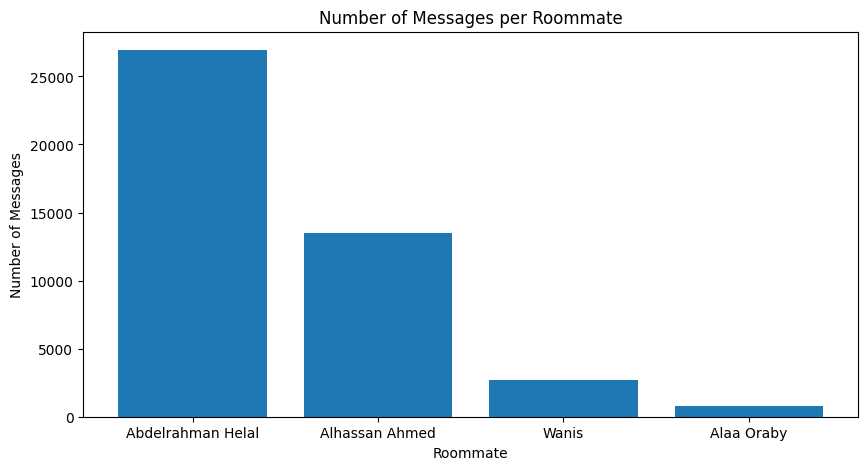

In [ ]:
# Messages distribution
message_counts = chat_roommates['from_name'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(message_counts.keys(), message_counts.values)
plt.xlabel('Roommate')
plt.ylabel('Number of Messages')
plt.title('Number of Messages per Roommate')
plt.show()


### Vectorization

In order to perform quantitative analysis on the text data, we first need to transform it into a numerical representation. We do so using the Term Frequency Inverse Document Frequency (TF-IDF) vectorizer. It basically counts the frequency of each word in one message and accounts for the frequency of the word across all messages to reduce the influence of highly common words (i.e. prepositions and connectors). In a more formal way, we say that

$$tfidf(t, d) = tf(t, d) \times idf(t),$$
$$ = tf(t, d) \times \log{\frac{n}{df(t)}} + 1, $$

where $tf(t, d)$ is the proportion of the word $t$ relative to all words in document $d$, $n$ is the number of documents, and $df(t)$ is the number of documents that contain $t$. Multiplying by the inverse log ensures that we reduce the weight of terms occuring in many documnets, but the extra 1 in $idf(t)$ ensures that we do not output 0 for terms that appear in all documents.

After vectorizing the texts, we print the first three messages and their vector form. The first message has two words, and its vector has two elements; the second messages has three words, and its vector has three elements, and so on. Furthemore, we print the words with the top 10 weights across all texts, and they are among the common words we use. The first three in English mean 'what', 'God', and 'but'.


In [ ]:
# Vectorizing messages and their senders
chat_roommates['sender_numerice'] = pd.factorize(chat_roommates['from_name'])[0]
texts, senders = np.array(chat_roommates['text']), np.array(chat_roommates['sender_numerice'])

vectorizer = TfidfVectorizer()
vec_texts = vectorizer.fit_transform(texts)

print(f'Shape of vec_texts: {vec_texts.shape}')


Shape of vec_texts: (43884, 30441)


## BERT Fine-Tuning

When I first used Naive Bayes, I applied to the text encoding with TF-IDF vectorizer. However, this approach has a limitation that it only depends on the words frequency and is not able to extract any context or meaning from the text. The **Bidirectional Encoder Representations from Transformers (BERT)** improves this by extracting meaning and context from the text. First it masks a fraction of the words and tries predicting them based on the surrouding words. Also, the "bidirectional" in the name corresponds to the way it processes texts. Unlike left-to-right models like RNNs, BERT considers botht the previous and following words when predicting the missing word, which provides meaningful context. $$$$



According to Devlin et al., (2019), from which the below image is adopted, the model defines the beginning and end of a sentence with two symbols: CLS and SEP, respictively. For each words, the model calculates three embedding values and adds them

$$ E [i] = E_{\text{token}}[i] + E_{\text{segment}} [i] + E_{\text{position}}[i], $$

where $E_{\text{position}}$ is the index of the word in the A-B sentence pai, and $E_{\text{segment}}$ defines whether the word belongs to sentence A or B.

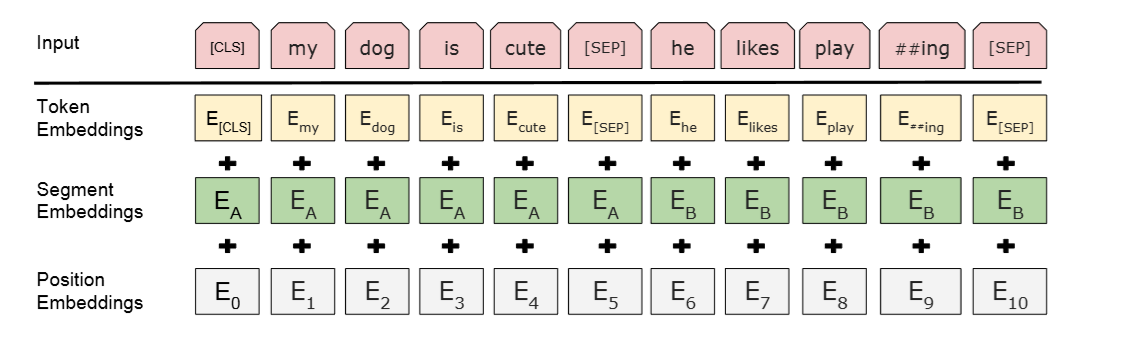

$$ $$

In my code, I use BERT-base, which uses 12 transformer layers, 12 attention heads, and 768 embedding dimensions. Each transformer block is based on the Transformer architecture shown below (Vaswani et al., 2017)

The main component in the architecture is the Multi-Head Self Attention block, which uses Scaled-Dot Product attention, which in, simple terms, calculates relations between tokens. After the input is processed to the BERT model, as explained above, we have $X$ with $B$ batches, $n$ sequence length, and $d$ dimensions. The transformer block, then, defines a query, key, and value for each token. The query says what the token searches for in other token; the key says what the token itself has, and the value says what the token returns to other queries.
These three are learned by matrices

$$Q = XW^{Q}, \quad K = XW^{K}, \quad V = XW^{V}.$$

The Scaled-Dot Product Attention is then calculated as

$$\text{Attention(Q, K, V)} = \text{Softmax}(\frac{QK^{T}}{\sqrt{d}})V .$$


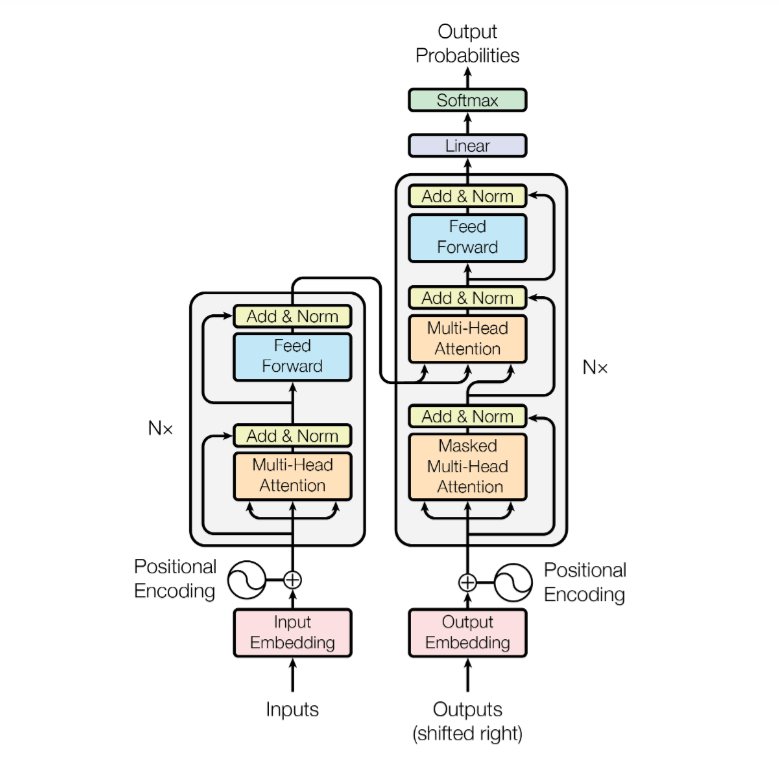


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from torch.utils.data import Dataset as TorchDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Custom Dataset class for PyTorch
class TextDataset(TorchDataset):
    """Custom PyTorch Dataset for text classification."""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("PyTorch Dataset class defined successfully!")


Using device: cuda
PyTorch Dataset class defined successfully!


### Sender Classification with Fine-Tuned BERT



In [ ]:
# Prepare data for fine-tuning
print("=== PREPARING DATA FOR BERT FINE-TUNING ===\n")

# Use the roommate messages we already have
label_to_id = {name: idx for idx, name in enumerate(roommates)}
id_to_label = {idx: name for name, idx in label_to_id.items()}

print(f"Label mapping: {label_to_id}\n")

# Prepare texts and labels
fine_tune_texts = chat_roommates['text'].tolist()
fine_tune_labels = [label_to_id[name] for name in chat_roommates['from_name']]

print(f"Total samples: {len(fine_tune_texts)}")
print(f"Label distribution:")
for name, idx in label_to_id.items():
    count = sum(1 for label in fine_tune_labels if label == idx)
    print(f"  {name}: {count} ({count/len(fine_tune_labels)*100:.1f}%)")

# Split into train, validation, and test sets
# 70% train, 15% validation, 15% test
X_train_ft, X_temp, y_train_ft, y_temp = train_test_split(
    fine_tune_texts, fine_tune_labels,
    test_size=0.3,
    random_state=42,
    stratify=fine_tune_labels
)

X_val_ft, X_test_ft, y_val_ft, y_test_ft = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain set: {len(X_train_ft)} samples")
print(f"Validation set: {len(X_val_ft)} samples")
print(f"Test set: {len(X_test_ft)} samples")


=== PREPARING DATA FOR BERT FINE-TUNING ===

Label mapping: {'Abdelrahman Helal': 0, 'Alhassan Ahmed': 1, 'Wanis': 2, 'Alaa Oraby': 3}

Total samples: 43884
Label distribution:
  Abdelrahman Helal: 26937 (61.4%)
  Alhassan Ahmed: 13478 (30.7%)
  Wanis: 2666 (6.1%)
  Alaa Oraby: 803 (1.8%)

Train set: 30718 samples
Validation set: 6583 samples
Test set: 6583 samples


In [ ]:
# Load tokenizer and model
model_name = 'bert-base-uncased'
num_labels = len(roommates)  # 4 classes

print(f"Loading model: {model_name}")
print(f"Number of classes: {num_labels}\n")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model.to(device)

print(f"Model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading model: bert-base-uncased
Number of classes: 4



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!
Model parameters: 109,485,316


In [ ]:
print("Creating PyTorch datasets...")
print("Note: Tokenization happens on-the-fly during training for efficiency\n")

if 'TextDataset' not in globals():
    raise ImportError("Please run the previous cell that defines TextDataset class")

train_dataset = TextDataset(X_train_ft, y_train_ft, tokenizer, max_length=128)
val_dataset = TextDataset(X_val_ft, y_val_ft, tokenizer, max_length=128)
test_dataset = TextDataset(X_test_ft, y_test_ft, tokenizer, max_length=128)

print("Datasets created successfully!")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Creating PyTorch datasets...
Note: Tokenization happens on-the-fly during training for efficiency

Datasets created successfully!
Train dataset size: 30718
Validation dataset size: 6583
Test dataset size: 6583


In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1 score."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Data collator for padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_sender_classifier',
    num_train_epochs=3,
    per_device_train_batch_size=4,  # REDUCED from 16 to 4 to save memory
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4, # Accumulate gradients over 4 steps (effective batch size = 4*4 = 16)
    warmup_steps=100,  # Learning rate warmup
    weight_decay=0.01,  # L2 regularization
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',  # Evaluate after each epoch
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=2,  # Keep only 2 checkpoints
    seed=42,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    dataloader_pin_memory=False,  # Disable pin memory to save RAM
    gradient_checkpointing=True,  # Trade compute for memory
)

# Clear CUDA cache before creating trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared")

# Enable gradient checkpointing in model (saves memory)
if hasattr(model, 'gradient_checkpointing_enable'):
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled")

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=data_collator,  # Add data collator for padding
)

print("Trainer created successfully!")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Training arguments: {training_args}")


CUDA cache cleared
Gradient checkpointing enabled


/tmp/ipython-input-2469674180.py:57: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer created successfully!
Effective batch size: 16
Training arguments: TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=False,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_ste

In [ ]:
# Fine-tune the model
print("=== STARTING FINE-TUNING ===\n")
print("This may take a while depending on your hardware...\n")
print(f"Using device: {device}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation steps: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}\n")

# Clear cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

try:
    trainer.train()
    print("\n=== FINE-TUNING COMPLETE ===")
except RuntimeError as e:
    if "out of memory" in str(e):
        print("\n❌ CUDA OUT OF MEMORY ERROR")

        # Clear cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        raise
    else:
        raise


=== STARTING FINE-TUNING ===

This may take a while depending on your hardware...

Using device: cuda
Batch size: 4
Gradient accumulation steps: 4
Effective batch size: 16



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abdelrahman-helal (abdelrahman-helal-minerva-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.640600,0.637439,0.738265,0.713684,0.738265,0.717884
2,0.613700,0.560432,0.775330,0.772122,0.775330,0.763720
3,0.430300,0.563963,0.780343,0.775499,0.780343,0.769908



=== FINE-TUNING COMPLETE ===


In [ ]:
# Evaluate on test set
print("=== EVALUATING ON TEST SET ===\n")

test_results = trainer.evaluate(test_dataset)
print("Test Set Results:")
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Get predictions for confusion matrix
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\n=== CONFUSION MATRIX ===")
print("Rows: True labels, Columns: Predicted labels")
print(f"{'':15s}", end="")
for name in roommates:
    print(f"{name[:10]:>12s}", end="")
print()
for i, name in enumerate(roommates):
    print(f"{name[:14]:15s}", end="")
    for j in range(len(roommates)):
        print(f"{cm[i, j]:12d}", end="")
    print()

# Per-class metrics
print("\n=== PER-CLASS METRICS ===")
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)
for i, name in enumerate(roommates):
    print(f"{name}:")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall:    {recall[i]:.4f}")
    print(f"  F1-Score:  {f1[i]:.4f}")
    print(f"  Support:   {support[i]}")
    print()


=== EVALUATING ON TEST SET ===



Test Set Results:
  eval_loss: 0.5607
  eval_accuracy: 0.7896
  eval_precision: 0.7878
  eval_recall: 0.7896
  eval_f1: 0.7802
  eval_runtime: 26.3492
  eval_samples_per_second: 249.8370
  eval_steps_per_second: 31.2340
  epoch: 3.0000

=== CONFUSION MATRIX ===
Rows: True labels, Columns: Predicted labels
                 Abdelrahma  Alhassan A       Wanis  Alaa Oraby
Abdelrahman He         3645         362          32           2
Alhassan Ahmed          644        1352          26           0
Wanis                   159          71         170           0
Alaa Oraby               72          16           1          31

=== PER-CLASS METRICS ===
Abdelrahman Helal:
  Precision: 0.8064
  Recall:    0.9020
  F1-Score:  0.8515
  Support:   4041

Alhassan Ahmed:
  Precision: 0.7507
  Recall:    0.6686
  F1-Score:  0.7073
  Support:   2022

Wanis:
  Precision: 0.7424
  Recall:    0.4250
  F1-Score:  0.5405
  Support:   400

Alaa Oraby:
  Precision: 0.9394
  Recall:    0.2583
  F1-Score:  0.4

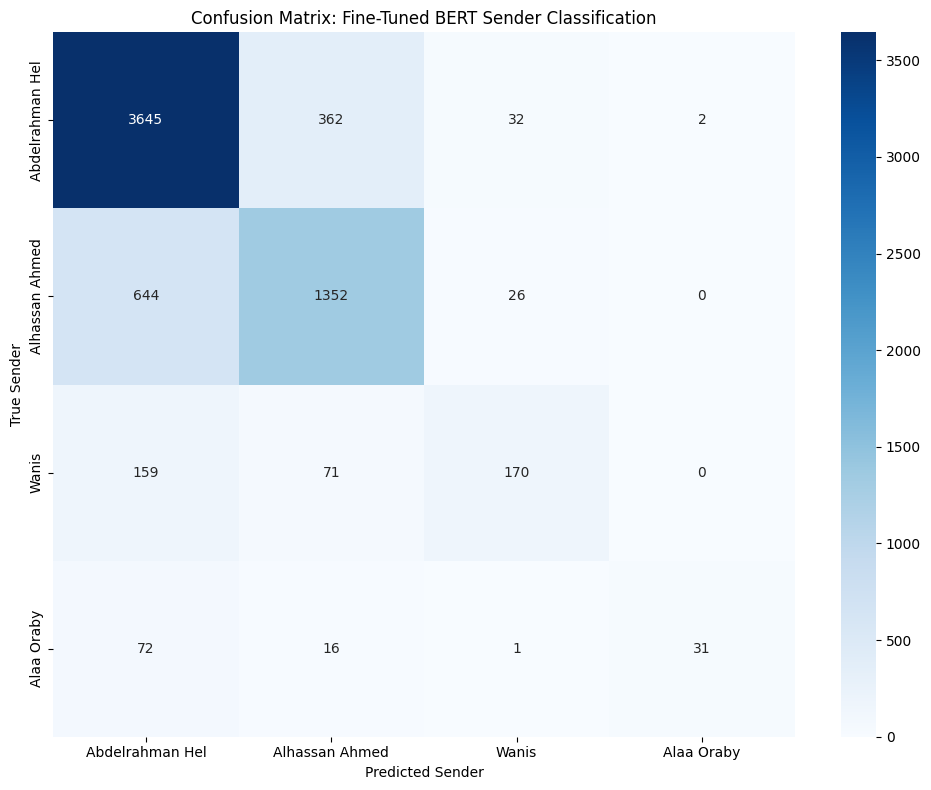

=== COMPARISON WITH NAIVE BAYES ===
(Run your Naive Bayes classification cell to compare)
Fine-tuned BERT Test Accuracy: 0.7896


In [ ]:
# Visualize confusion matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[name[:15] for name in roommates],
            yticklabels=[name[:15] for name in roommates],
            ax=ax)
ax.set_xlabel('Predicted Sender')
ax.set_ylabel('True Sender')
ax.set_title('Confusion Matrix: Fine-Tuned BERT Sender Classification')
plt.tight_layout()
plt.show()

# Compare with Naive Bayes results (if available)
print("=== COMPARISON WITH NAIVE BAYES ===")
print("(Run your Naive Bayes classification cell to compare)")
print("Fine-tuned BERT Test Accuracy:", f"{test_results['eval_accuracy']:.4f}")


As can be seen from the confusion matrix, the fine-tuned BERT model has an overall accuracy of ~79%, but it still identifies majority of the messages, especially for Wanis and Alaa as Abdelrahman, which happens because of the significant class imbalance. We can say that class imbalance remains a significant challenge even for highly complex models.

## K-Means Clustering Analysis

In the following section, we work on a new task, which is identifying clusters in the text messages. We apply K-Means clustering to the messages using two different embedding approaches:
1. **TF-IDF vectors**: Direct use of the TF-IDF vectorized text
2. **SBERT embeddings**: Sentence-BERT embeddings created from scratch using BERT


### K-Means Clustering on TF-IDF Vectors

By investigating the cluster distribution on the TF-IDF vectors, we see that Cluster 2 has the majority of the messages (43738) with incomparable numbers for the other 3 clusters. We also apply PCA on the vectors and visualize the clusters on the first two principal components, and we can see that the whole plot is mainly made of cluster 2. An interesting observation is that the total variance explained by the first two components is only 0.019, which is the primary reason why we do not see clear patterns or information in the PCA plots.


In [ ]:
# K-Means clustering on TF-IDF vectors
print("=== K-MEANS CLUSTERING ON TF-IDF VECTORS ===")
print(f"TF-IDF vectors shape: {vec_texts.shape}")

from sklearn.cluster import MiniBatchKMeans

kmeans_tfidf = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=1000, n_init=10)
cluster_labels_tfidf = kmeans_tfidf.fit_predict(vec_texts)

print(f"K-means clustering completed")
print(f"Cluster distribution: {np.bincount(cluster_labels_tfidf)}")

# Compare clusters with actual labels
print(f"\n=== CLUSTER VS CLASS COMPARISON (TF-IDF) ===")
for i in range(4):
    cluster_mask = cluster_labels_tfidf == i
    actual_classes = senders[cluster_mask]
    print(f"Cluster {i}: {len(actual_classes)} samples")
    print(f"  Class distribution: {np.bincount(actual_classes, minlength=3)}")
    print()

=== K-MEANS CLUSTERING ON TF-IDF VECTORS ===
TF-IDF vectors shape: (43884, 30441)
K-means clustering completed
Cluster distribution: [  139     1 43738     6]

=== CLUSTER VS CLASS COMPARISON (TF-IDF) ===
Cluster 0: 139 samples
  Class distribution: [92 39  4  4]

Cluster 1: 1 samples
  Class distribution: [0 0 0 1]

Cluster 2: 43738 samples
  Class distribution: [26843 13435  2662   798]

Cluster 3: 6 samples
  Class distribution: [2 4 0]



=== PCA VISUALIZATION FOR TF-IDF CLUSTERING ===
PCA explained variance ratio: [0.01018366 0.00884904]
Total variance explained: 0.019


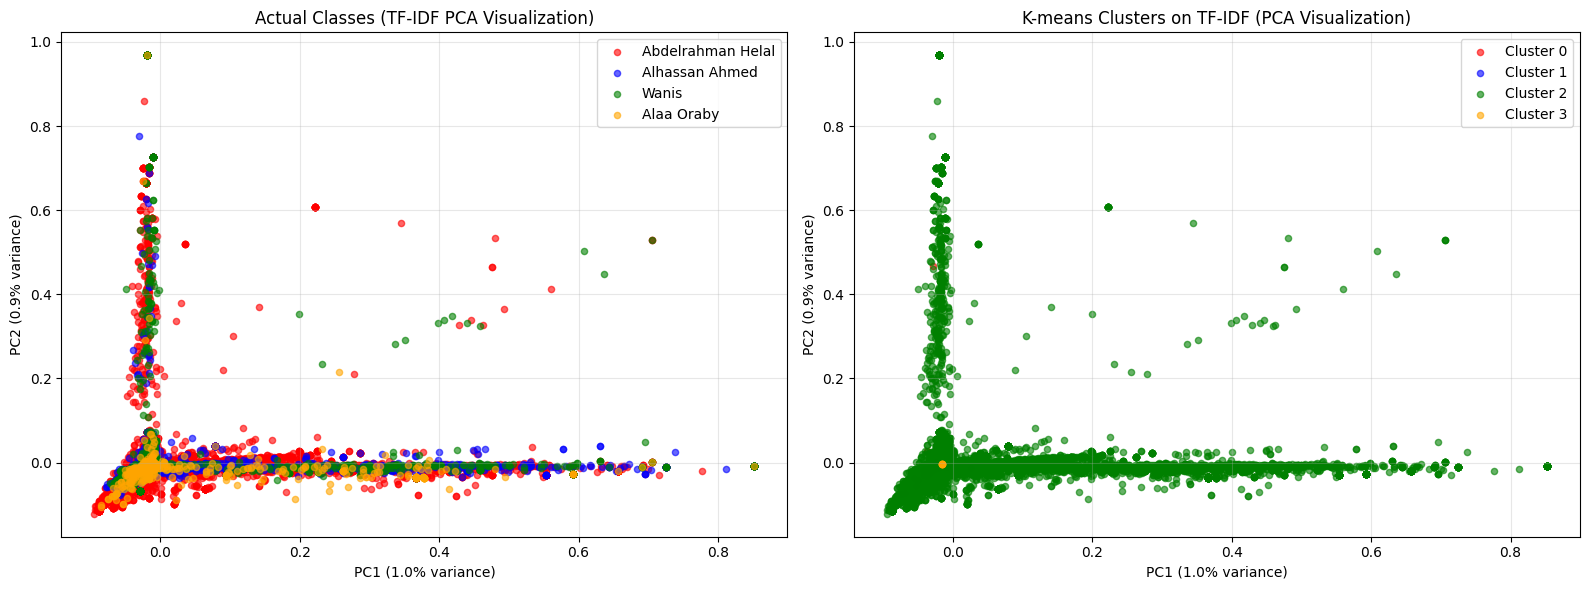

In [ ]:
# PCA visualization for TF-IDF clustering
from sklearn.decomposition import PCA
print("=== PCA VISUALIZATION FOR TF-IDF CLUSTERING ===")

# Apply PCA to reduce TF-IDF vectors to 2D
pca_tfidf = PCA(n_components=2, random_state=42)
vec_texts_pca = pca_tfidf.fit_transform(vec_texts)

print(f"PCA explained variance ratio: {pca_tfidf.explained_variance_ratio_}")
print(f"Total variance explained: {pca_tfidf.explained_variance_ratio_.sum():.3f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual classes (TF-IDF)
class_names = ['Abdelrahman Helal', 'Alhassan Ahmed', 'Wanis', 'Alaa Oraby']
colors = ['red', 'blue', 'green', 'orange']
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = senders == i
    axes[0].scatter(vec_texts_pca[mask, 0], vec_texts_pca[mask, 1],
                    c=color, label=name, alpha=0.6, s=20)

axes[0].set_title('Actual Classes (TF-IDF PCA Visualization)')
axes[0].set_xlabel(f'PC1 ({pca_tfidf.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_tfidf.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: K-means clusters (TF-IDF)
cluster_colors = ['red', 'blue', 'green', 'orange']
for i, color in enumerate(cluster_colors):
    mask = cluster_labels_tfidf == i
    axes[1].scatter(vec_texts_pca[mask, 0], vec_texts_pca[mask, 1],
                   c=color, label=f'Cluster {i}', alpha=0.6, s=20)

axes[1].set_title('K-means Clusters on TF-IDF (PCA Visualization)')
axes[1].set_xlabel(f'PC1 ({pca_tfidf.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_tfidf.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### K-Means Clustering on BERT Embedding


We encode the text into vectors using the BERT base model. BERT works on pairs of sentences that need to be of equal length, so we add padding tokens that increase the length of shorter sentence to make them of equal length. In the last step, we apply mean pooling and L2 normalization ($|x|_2 = \sqrt{x_1^2 + x_2^2 + x_3^2 ...}  $)  to get the final encoding of dimension 768.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


In [ ]:
# SBERT implementation from scratch
class SBERT:
    """
    Sentence-BERT implementation from scratch.
    Uses mean pooling of BERT token embeddings to create sentence embeddings.
    """
    def __init__(self, model_name='bert-base-uncased', device=None):
        """
        Initialize SBERT model.

        Args:
            model_name: HuggingFace model name (default: 'bert-base-uncased')
            device: torch device ('cuda' or 'cpu'), auto-detected if None
        """
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        print(f"Loading BERT model: {model_name}")
        print(f"Using device: {self.device}")

        # Load tokenizer and model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()  # Set to evaluation mode

    def encode(self, sentences, batch_size=32, show_progress=False):
        """
        Encode sentences into embeddings using mean pooling.

        Args:
            sentences: List of strings or single string
            batch_size: Batch size for processing
            show_progress: Whether to show progress bar

        Returns:
            numpy array of shape (n_sentences, embedding_dim)
        """
        # Handle single sentence
        if isinstance(sentences, str):
            sentences = [sentences]

        all_embeddings = []

        # Process in batches
        n_batches = (len(sentences) + batch_size - 1) // batch_size

        for i in range(0, len(sentences), batch_size):
            batch = sentences[i:i + batch_size]

            # Tokenize
            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )

            # Move to device
            encoded = {k: v.to(self.device) for k, v in encoded.items()}

            # Get BERT embeddings
            with torch.no_grad():
                outputs = self.model(**encoded)
                # outputs.last_hidden_state shape: (batch_size, seq_len, hidden_size)
                token_embeddings = outputs.last_hidden_state

                # Mean pooling: average all token embeddings (excluding padding)
                # attention_mask: 1 for real tokens, 0 for padding
                attention_mask = encoded['attention_mask']

                # Expand attention mask to match embedding dimensions
                mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

                # Sum embeddings, masking out padding tokens
                sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)

                # Sum of mask values (number of real tokens per sentence)
                sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)

                # Mean pooling: divide by number of real tokens
                mean_embeddings = sum_embeddings / sum_mask

                # Normalize embeddings (L2 normalization)
                normalized_embeddings = F.normalize(mean_embeddings, p=2, dim=1)

                all_embeddings.append(normalized_embeddings.cpu().numpy())

        # Concatenate all batches
        embeddings = np.vstack(all_embeddings)
        return embeddings

# Initialize SBERT model
print("=== INITIALIZING SBERT MODEL ===")
sbert = SBERT(model_name='bert-base-uncased')


=== INITIALIZING SBERT MODEL ===
Loading BERT model: bert-base-uncased
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Generate SBERT embeddings for all messages
print("=== GENERATING SBERT EMBEDDINGS ===")
print(f"Processing {len(texts)} messages...")

# Convert texts to list if needed
texts_list = texts.tolist() if isinstance(texts, np.ndarray) else list(texts)

# Generate embeddings (this may take a while for large datasets)
sbert_embeddings = sbert.encode(texts_list, batch_size=32, show_progress=True)

print(f"SBERT embeddings shape: {sbert_embeddings.shape}")
print(f"Embedding dimension: {sbert_embeddings.shape[1]}")


=== GENERATING SBERT EMBEDDINGS ===
Processing 43884 messages...
SBERT embeddings shape: (43884, 768)
Embedding dimension: 768


In [ ]:
# K-Means clustering on SBERT embeddings
print("=== K-MEANS CLUSTERING ON SBERT EMBEDDINGS ===")
print(f"SBERT embeddings shape: {sbert_embeddings.shape}")

# Apply K-means with 3 clusters
kmeans_sbert = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_sbert = kmeans_sbert.fit_predict(sbert_embeddings)

print(f"K-means clustering completed")
print(f"Cluster distribution: {np.bincount(cluster_labels_sbert)}")

# Compare clusters with actual labels
print(f"\n=== CLUSTER VS CLASS COMPARISON (SBERT) ===")
for i in range(4):
    cluster_mask = cluster_labels_sbert == i
    actual_classes = senders[cluster_mask]
    print(f"Cluster {i}: {len(actual_classes)} samples")
    print(f"  Class distribution: {np.bincount(actual_classes, minlength=3)}")
    print()


=== K-MEANS CLUSTERING ON SBERT EMBEDDINGS ===
SBERT embeddings shape: (43884, 768)
K-means clustering completed
Cluster distribution: [ 8423  3569 26456  5436]

=== CLUSTER VS CLASS COMPARISON (SBERT) ===
Cluster 0: 8423 samples
  Class distribution: [4392 3513  415  103]

Cluster 1: 3569 samples
  Class distribution: [2405  950  132   82]

Cluster 2: 26456 samples
  Class distribution: [15015  8742  2093   606]

Cluster 3: 5436 samples
  Class distribution: [5125  273   26   12]



=== PCA VISUALIZATION FOR SBERT CLUSTERING ===
PCA explained variance ratio: [0.39865863 0.08294258]
Total variance explained: 0.482


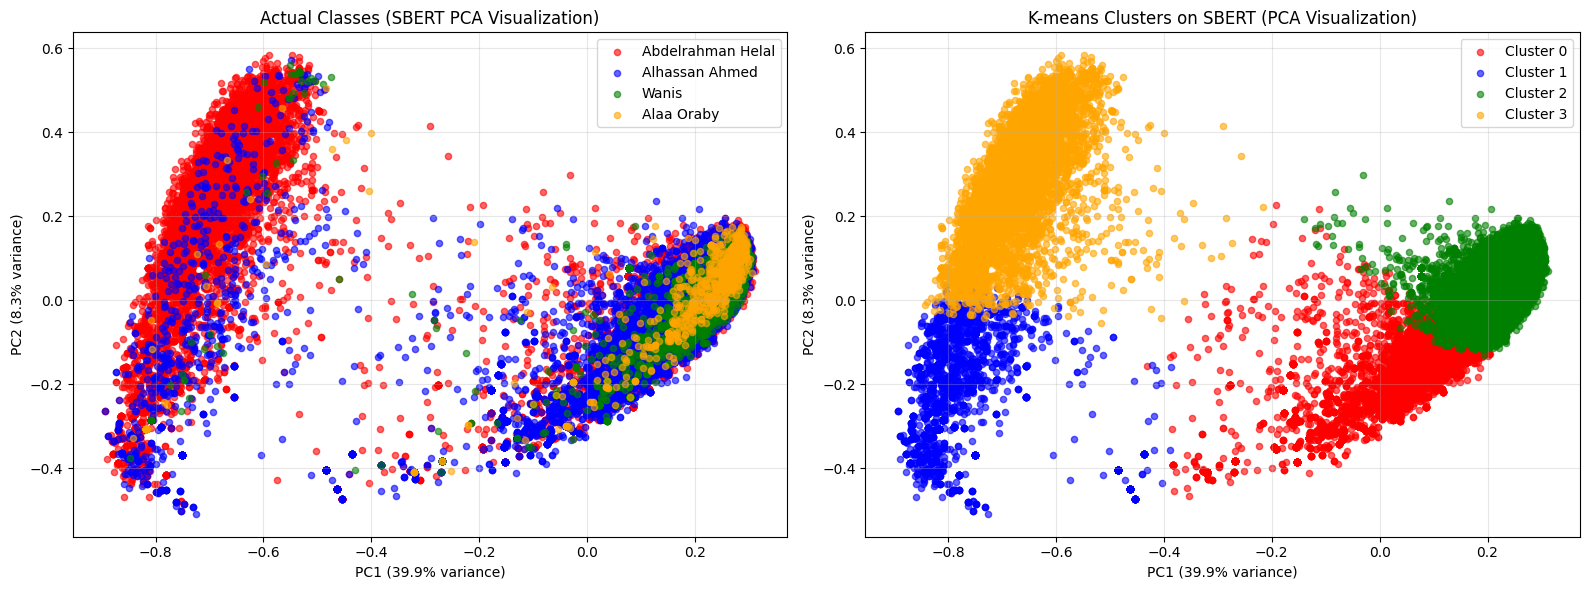

In [ ]:
# PCA visualization for SBERT clustering
print("=== PCA VISUALIZATION FOR SBERT CLUSTERING ===")

class_names = ['Abdelrahman Helal', 'Alhassan Ahmed', 'Wanis', 'Alaa Oraby']
# Apply PCA to reduce SBERT embeddings to 2D
pca_sbert = PCA(n_components=2, random_state=42)
sbert_embeddings_pca = pca_sbert.fit_transform(sbert_embeddings)

print(f"PCA explained variance ratio: {pca_sbert.explained_variance_ratio_}")
print(f"Total variance explained: {pca_sbert.explained_variance_ratio_.sum():.3f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual classes (SBERT)
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = senders == i
    axes[0].scatter(sbert_embeddings_pca[mask, 0], sbert_embeddings_pca[mask, 1],
                    c=color, label=name, alpha=0.6, s=20)

axes[0].set_title('Actual Classes (SBERT PCA Visualization)')
axes[0].set_xlabel(f'PC1 ({pca_sbert.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_sbert.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: K-means clusters (SBERT)
for i, color in enumerate(cluster_colors):
    mask = cluster_labels_sbert == i
    axes[1].scatter(sbert_embeddings_pca[mask, 0], sbert_embeddings_pca[mask, 1],
                   c=color, label=f'Cluster {i}', alpha=0.6, s=20)

axes[1].set_title('K-means Clusters on SBERT (PCA Visualization)')
axes[1].set_xlabel(f'PC1 ({pca_sbert.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_sbert.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The principal components of the BERT embedding explain 48% of the variance, and we see that there is a lot of overlap between the 4 senders in the left PCA plot. However, the right PCA plot shows 4 distinct cluster with minimal overlap between the clusters, which is a significant improvement from the clusters applied to the TF-IDF vectors directly.
$$$$

To have a better understanding of these clusters, we print the top words for each cluster below.
- Cluster 0 mainly consists of the very common slang Arabic words, such as "Sure", "Lol", "God", and "My love", which likely appears in all senders's messages.
- Cluster 1 mainly consists of affirming and declining words (like yes and no), and interstingly, it has three Arabic words that mean "yes" and "done", so the model was able to capture multilingual similarity.
- Clusters 2 and 3 are connective phrases, but one is in Arabic and the other is in English.  


### Top Words Analysis for SBERT Clusters



In [ ]:
# Analyze top words in each SBERT cluster
from collections import Counter
import re

print("=== TOP WORDS ANALYSIS FOR SBERT CLUSTERS ===\n")

# Get unique cluster labels
n_clusters = len(np.unique(cluster_labels_sbert))
print(f"Number of clusters: {n_clusters}\n")

# Function to tokenize and clean text
def tokenize_text(text):
    """Tokenize text into words, handling Arabic and English."""
    if not text or pd.isna(text):
        return []
    # Convert to string and lowercase
    text = str(text).lower()
    # Split on whitespace and punctuation
    # This works for both Arabic and English
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Analyze each cluster
for cluster_id in range(4):
    # Get messages in this cluster
    cluster_mask = cluster_labels_sbert == cluster_id
    cluster_messages = texts[cluster_mask]

    print(f"--- Cluster {cluster_id} ({np.sum(cluster_mask)} messages) ---")

    # Count words in this cluster
    all_words = []
    for msg in cluster_messages:
        words = tokenize_text(msg)
        all_words.extend(words)

    # Count word frequencies
    word_counts = Counter(all_words)

    # Get top 20 words
    top_words = word_counts.most_common(20)

    # Display top words
    print("Top 20 words:")
    for i, (word, count) in enumerate(top_words, 1):
        percentage = (count / len(all_words)) * 100 if all_words else 0
        print(f"  {i:2d}. {word:15s} ({count:5d} times, {percentage:5.2f}%)")

    # Show sample messages from this cluster
    print(f"\nSample messages from Cluster {cluster_id}:")
    sample_indices = np.where(cluster_mask)[0][:3]  # First 3 messages
    for idx in sample_indices:
        msg_text = texts[idx][:100]  # First 100 characters
        sender_name = chat_roommates.iloc[idx]['from_name']
        print(f"  [{sender_name}]: {msg_text}...")

    print("\n" + "="*60 + "\n")


=== TOP WORDS ANALYSIS FOR SBERT CLUSTERS ===

Number of clusters: 4

--- Cluster 0 (8423 messages) ---
Top 20 words:
   1. لا              (  323 times,  2.54%)
   2. اشطا            (  281 times,  2.21%)
   3. لول             (  258 times,  2.03%)
   4. اه              (  239 times,  1.88%)
   5. اها             (  232 times,  1.83%)
   6. ايه             (  232 times,  1.83%)
   7. باشا            (  218 times,  1.72%)
   8. تمام            (  192 times,  1.51%)
   9. مش              (  180 times,  1.42%)
  10. يب              (  178 times,  1.40%)
  11. حبيبي           (  176 times,  1.39%)
  12. اي              (  170 times,  1.34%)
  13. ده              (  158 times,  1.24%)
  14. بس              (  126 times,  0.99%)
  15. احم             (  125 times,  0.98%)
  16. ربنا            (  122 times,  0.96%)
  17. ايوه            (  117 times,  0.92%)
  18. في              (  110 times,  0.87%)
  19. يارب            (  107 times,  0.84%)
  20. طب              (  104 times,  0.82%)

S

## Hyperparameter Tuning - Number of Clusters


I try different numbers of clusters on the BERT embedding to determine the optimal number of clusters that are able to capture most of the difference between the tokens. In doing so, I use three comparison metrics:

### Silhoute Score
It measures how similar each point is to its cluster relative to other clusters, and it is calculated as a score for each point $i$ and is averaged over all $n$ points in the cluster:

$$S = \frac{1}{N} \sum_i^n s(i),$$

where

$$s(i) = \frac{b(i) - a(i)}{\max (a(i), b(i))},$$

given that $a(i)$ is the average distance from $i$ to other points in its cluster and $b(i)$ is the shortest average distance to another cluster.

### Davies Bouldin (DB) Score

We first calculate the scatter within each cluster:

$$
S_i = \frac{1}{|C_i|} \sum_{x \in C_i} \| x - \mu_i \|
$$

Then, we calculate the distance between the clusters centers

$$
M_{ij} = \| \mu_i - \mu_j \|
$$

And the similarity between clusters i and j

$$
R_{ij} = \frac{S_i + S_j}{M_{ij}}
$$

Lastly, we find the highest similarity with other cluster for cluster $i$

$$
R_i = \max_{j \ne i} R_{ij}
$$

So, we can write the final DB score using the above variables as follows
$$
DB = \frac{1}{k} \sum_{i=1}^{k} R_i
$$

### Calinski–Harabasz Index (Variance Ratio Criterion)

It shows the trade off between the separation between the clusters centroids and the compactness of each cluster.

Let:
- k = number of clusters
- n = total number of samples
- \mu = global centroid
- \mu_i = centroid of cluster C_i
- |C_i| = number of samples in cluster i
- B_k = between-cluster dispersion
- W_k = within-cluster dispersion

So, we first calculate two metrics:

1. Between-cluster dispersion

$$
B_k = \sum_{i=1}^{k} |C_i| \, \| \mu_i - \mu \|^2
$$

2. Within-cluster dispersion

$$
W_k = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

Then, the Calinski–Harabasz score is given by

$$
CH = \frac{B_k / (k - 1)}{W_k / (n - k)}
$$

The code below shows that the optimal number of clusters is 2, which is reasonable, as we could see a right-hand side cluster and a left-side cluster that are clearly seperable.

=== OPTIMAL NUMBER OF CLUSTERS ANALYSIS ===

Using sample of 5000 messages for cluster evaluation

k=2: Silhouette=0.4782, DB=1.2241, CH=2860.10
k=3: Silhouette=0.4694, DB=1.8643, CH=1755.46
k=4: Silhouette=0.2172, DB=2.2379, CH=1413.03
k=5: Silhouette=0.2299, DB=2.0313, CH=1211.54
k=6: Silhouette=0.1336, DB=2.0870, CH=1062.04
k=7: Silhouette=0.1342, DB=2.1332, CH=930.19
k=8: Silhouette=0.1181, DB=2.4203, CH=826.10
k=9: Silhouette=0.1124, DB=2.7715, CH=745.56
k=10: Silhouette=0.1030, DB=2.7491, CH=679.45


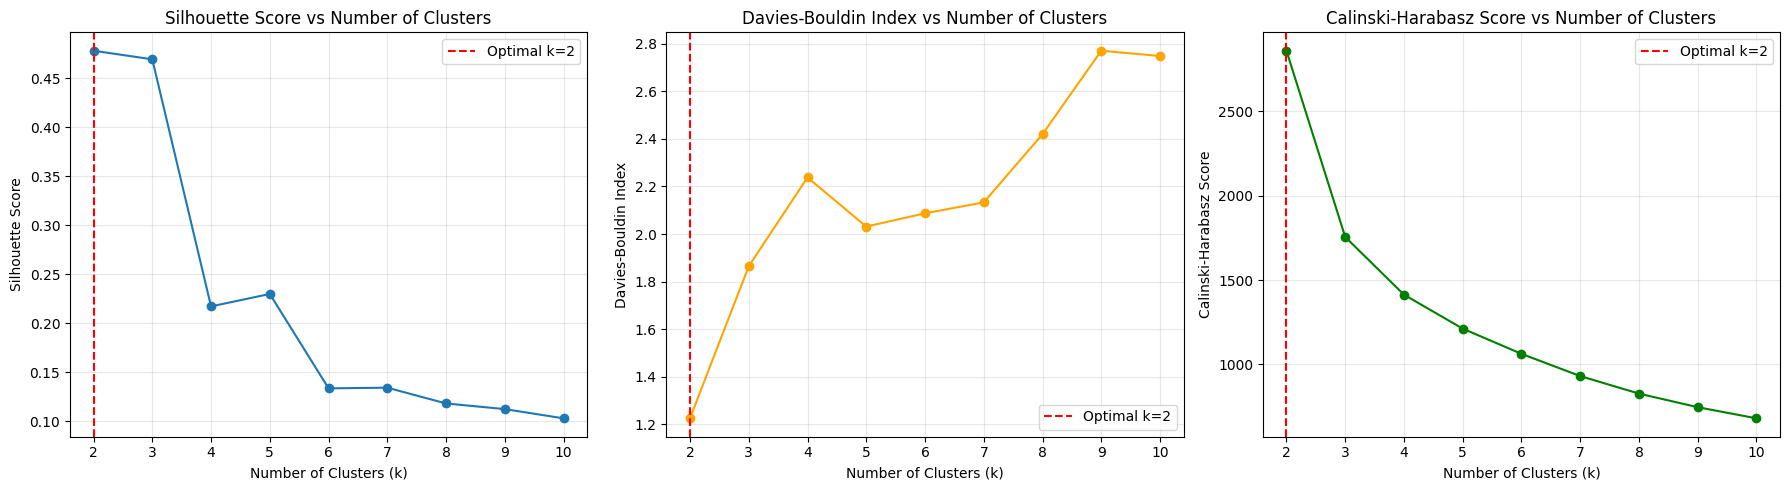


Recommended k based on:
  Silhouette Score: k=2
  Davies-Bouldin Index: k=2
  Calinski-Harabasz Score: k=2


In [ ]:
# Example: Optimal Number of Clusters Analysis
print("=== OPTIMAL NUMBER OF CLUSTERS ANALYSIS ===\n")

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Test different numbers of clusters
k_range = range(2, 11)
silhouette_scores = []
db_scores = []
ch_scores = []

# Sample data for faster computation (if dataset is large)
sample_size = min(5000, len(sbert_embeddings))
if len(sbert_embeddings) > 5000:
    sample_indices = np.random.choice(len(sbert_embeddings), sample_size, replace=False)
    embeddings_sample = sbert_embeddings[sample_indices]
    print(f"Using sample of {sample_size} messages for cluster evaluation\n")
else:
    embeddings_sample = sbert_embeddings
    sample_indices = np.arange(len(sbert_embeddings))

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_sample)

    silhouette = silhouette_score(embeddings_sample, labels)
    db = davies_bouldin_score(embeddings_sample, labels)
    ch = calinski_harabasz_score(embeddings_sample, labels)

    silhouette_scores.append(silhouette)
    db_scores.append(db)
    ch_scores.append(ch)

    print(f"k={k}: Silhouette={silhouette:.4f}, DB={db:.4f}, CH={ch:.2f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette score (higher is better)
axes[0].plot(k_range, silhouette_scores, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=k_range[np.argmax(silhouette_scores)], color='r', linestyle='--',
                label=f'Optimal k={k_range[np.argmax(silhouette_scores)]}')
axes[0].legend()

# Davies-Bouldin index (lower is better)
axes[1].plot(k_range, db_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index vs Number of Clusters')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=k_range[np.argmin(db_scores)], color='r', linestyle='--',
                label=f'Optimal k={k_range[np.argmin(db_scores)]}')
axes[1].legend()

# Calinski-Harabasz score (higher is better)
axes[2].plot(k_range, ch_scores, marker='o', color='green')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs Number of Clusters')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=k_range[np.argmax(ch_scores)], color='r', linestyle='--',
                label=f'Optimal k={k_range[np.argmax(ch_scores)]}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nRecommended k based on:")
print(f"  Silhouette Score: k={k_range[np.argmax(silhouette_scores)]}")
print(f"  Davies-Bouldin Index: k={k_range[np.argmin(db_scores)]}")
print(f"  Calinski-Harabasz Score: k={k_range[np.argmax(ch_scores)]}")


## References

Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob
Uszkoreit, Llion Jones, Aidan N Gomez, Lukasz
Kaiser, and Illia Polosukhin. 2017. Attention is all
you need. In Advances in Neural Information Processing Systems, pages 6000–6010.
$$$$

Jacob Devlin, Ming-Wei Chang, Kenton Lee, and
Kristina Toutanova. 2019. BERT: Pre-training of
deep bidirectional transformers for language understanding. In North American Association for Computational Linguistics (NAACL).